In [1]:
import pandas as pd
import scanpy as sc 
import scanpy.external as sce
import matplotlib.pyplot as plt
import seaborn as sns
import anndata as ad
import numpy as np

In [2]:
def read_10x_manually(dir_datset, main_celltype):
    adata = sc.read_mtx(filename= dir_datset + '/seu_final/matrix.mtx')
    adata_bc=pd.read_csv(filepath_or_buffer= dir_datset + '/seu_final/barcodes.tsv', header=None)
    adata_features=pd.read_csv(filepath_or_buffer= dir_datset + '/seu_final/features.tsv',header=None)
    adata_obs=pd.read_csv(filepath_or_buffer= dir_datset + '/seu_final/metadata.tsv', sep='\t')
    adata= adata.T
    adata.obs=adata_obs
    adata.obs.index=adata_bc[0].tolist()
    adata.var['gene_name']= adata_features[0].tolist()
    adata.var.index= adata.var['gene_name']
    adata = adata[adata.obs['celltype_main'] == main_celltype, :]
    print(adata.obs['cohort'].unique())
    return adata

In [ ]:
dataset_names = ['SKCM_Becker', 'SKCM_Plozniak', 'BCC_Yost', 'SCC_Yost', 
             'BRCA_Bassez1', 'BRCA_Bassez2', 'TNBC_Zhang', 'TNBC_Shiao', 
             'HNSC_Franken', 'HNSC_vanderLeun', 'HNSC_Luoma', 
             'NSCLC_Yan', 'NSCLC_Liu',
             'CRC_Li', 'CRC_Chen', 'PCa_Hawley','HCC_Guo','RCC_Bi']
datasets = [read_10x_manually(dir_datset='/bigdata/zlin/PanCancer_ICI/data/' + name, main_celltype='CD4+T') for name in dataset_names]

['SKCM_this study']


/tmp/ipykernel_2819780/3031863817.py:5: DtypeWarning: Columns (32) have mixed types. Specify dtype option on import or set low_memory=False.
  adata_obs=pd.read_csv(filepath_or_buffer= dir_datset + '/seu_final/metadata.tsv', sep='\t')


['SKCM_Plozniak']


/tmp/ipykernel_2819780/3031863817.py:5: DtypeWarning: Columns (34) have mixed types. Specify dtype option on import or set low_memory=False.
  adata_obs=pd.read_csv(filepath_or_buffer= dir_datset + '/seu_final/metadata.tsv', sep='\t')


['BCC_Yost']
['SCC_Yost']
['BRCA_Bassez1']
['BRCA_Bassez2']
['TNBC_Zhang']
['TNBC_Shiao']
['HNSC_Franken']
['HNSC_vanderLeun']
['HNSC_Luoma']
['NSCLC_Yan']
['NSCLC_Liu']
['CRC_Li']
['CRC_Chen']
['PCa_Hawley']
['HCC_Guo']
['RCC_Bi']


In [22]:
adata = ad.concat(datasets, join='outer')
adata.obs = adata.obs.loc[:,['celltype_r2','celltype_main','cohort','patient','time_point','treatment']]

/bigdata/zlin/miniconda3/envs/scrna/lib/python3.9/site-packages/anndata/_core/anndata.py:1906: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


In [23]:
# maximum number of columns
pd.options.display.max_columns = None
pd.options.display.max_rows = None

In [25]:
sc.pp.normalize_total(adata)
sc.pp.log1p(adata)
adata.raw = adata
sc.pp.highly_variable_genes(adata)
sc.pp.scale(adata)
sc.pp.pca(adata)
sc.external.pp.bbknn(adata, batch_key='cohort')
sc.tl.umap(adata)

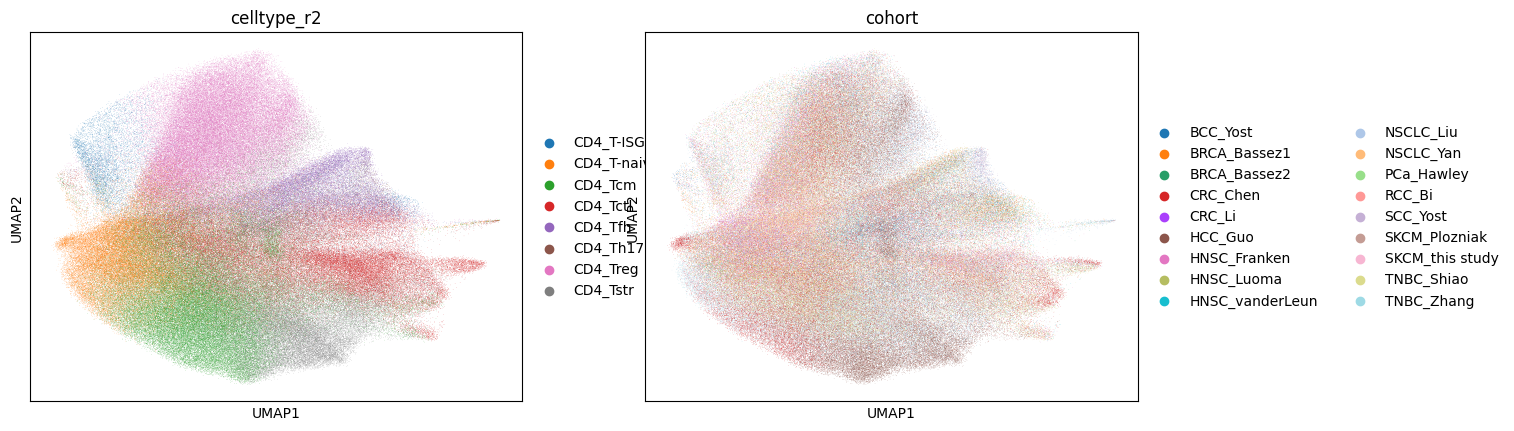

In [26]:
sc.pl.umap(adata, color=['celltype_r2','cohort'])

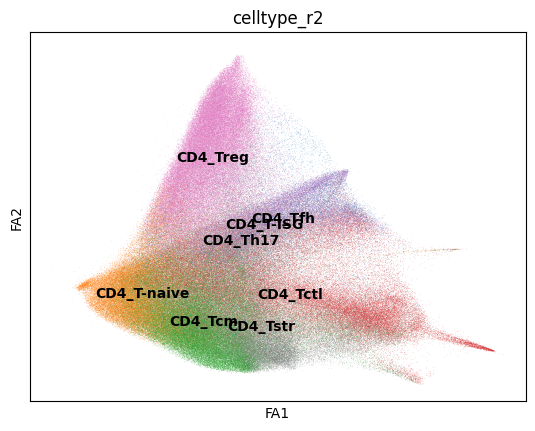

In [27]:
# use the umap to initialize the graph layout.
sc.tl.draw_graph(adata, init_pos='X_umap')
sc.pl.draw_graph(adata, color='celltype_r2', legend_loc='on data')

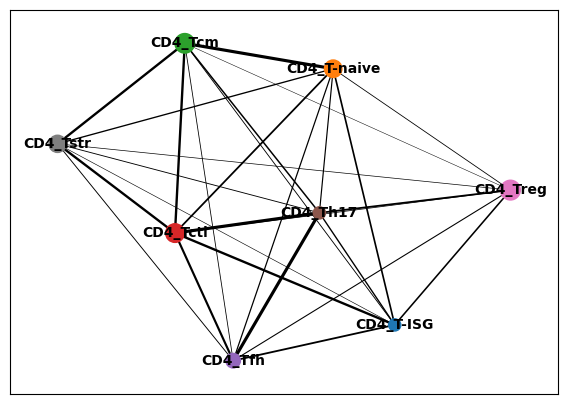

In [28]:
sc.tl.paga(adata, groups='celltype_r2')
sc.pl.paga(adata, color='celltype_r2', edge_width_scale = 0.3)

In [30]:
adata

AnnData object with n_obs × n_vars = 360199 × 27973
    obs: 'celltype_r2', 'celltype_main', 'cohort', 'patient', 'time_point', 'treatment'
    var: 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'mean', 'std'
    uns: 'log1p', 'hvg', 'pca', 'neighbors', 'umap', 'celltype_r2_colors', 'cohort_colors', 'draw_graph', 'paga', 'celltype_r2_sizes'
    obsm: 'X_pca', 'X_umap', 'X_draw_graph_fa'
    varm: 'PCs'
    obsp: 'distances', 'connectivities'

In [31]:
adata.uns['iroot'] = np.flatnonzero(adata.obs['celltype_r2']  == 'CD4_T-naive')[0]
sc.tl.dpt(adata)

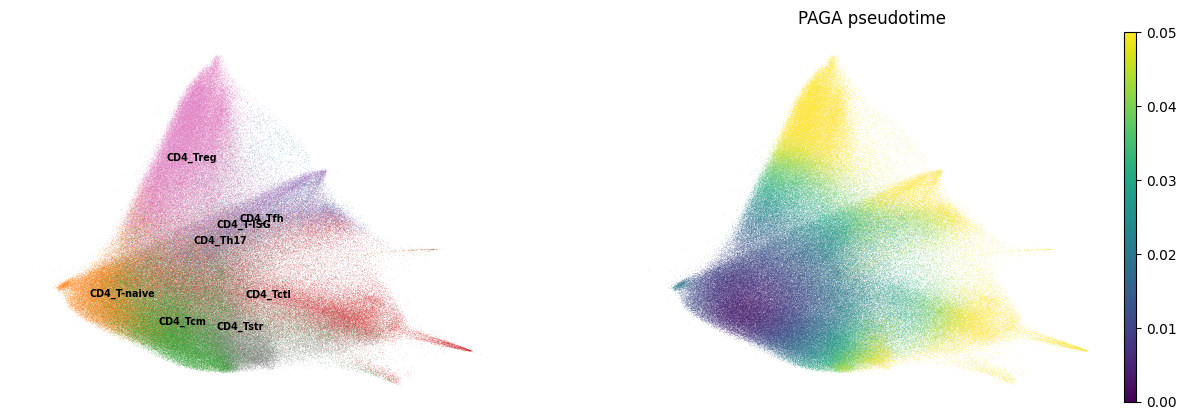

In [49]:
sc.pl.draw_graph(adata, color=['celltype_r2', 'dpt_pseudotime'], legend_loc='on data', legend_fontsize= 'x-small', vmax=0.05, frameon=False, title = ['','PAGA pseudotime'])

In [56]:
adata.obs.to_csv('/bigdata/zlin/PanCancer_ICI/tables/cd4t_paga.csv')

In [2]:
df=pd.read_csv('/bigdata/zlin/PanCancer_ICI/tables/cd4t_paga.csv', index_col=0)

In [3]:
df.head() 

,celltype_r2,celltype_main,cohort,patient,time_point,treatment,dpt_pseudotime
ACGCAGCAGTAGCGGT-1_1,CD4_Tfh,CD4+T,SKCM_this study,SKCM_this study_Patient7,Pre,aPD1,0.027047
ACGGGTCAGCCACCTG-1_1,CD4_Treg,CD4+T,SKCM_this study,SKCM_this study_Patient7,Pre,aPD1,0.015780
AGCGGTCAGGGAAACA-1_1,CD4_Tctl,CD4+T,SKCM_this study,SKCM_this study_Patient7,Pre,aPD1,0.033461
CACCTTGAGTGATCGG-1_1,CD4_Tctl,CD4+T,SKCM_this study,SKCM_this study_Patient7,Pre,aPD1,0.011510
CAGATCAGTGACAAAT-1_1,CD4_Treg,CD4+T,SKCM_this study,SKCM_this study_Patient7,Pre,aPD1,0.042014


In [ ]:
dataset_names = ['SKCM_Becker', 'SKCM_Plozniak', 'BCC_Yost', 'SCC_Yost', 
             'BRCA_Bassez1', 'BRCA_Bassez2', 'TNBC_Zhang', 'TNBC_Shiao', 
             'HNSC_Franken', 'HNSC_vanderLeun', 'HNSC_Luoma', 
             'NSCLC_Yan', 'NSCLC_Liu',
             'CRC_Li', 'CRC_Chen', 'PCa_Hawley','HCC_Guo','RCC_Bi']
datasets = [read_10x_manually(dir_datset='/bigdata/zlin/PanCancer_ICI/data/' + name, main_celltype='CD8+T') for name in dataset_names]

['SKCM_this study']


/tmp/ipykernel_2925865/2627459322.py:5: DtypeWarning: Columns (32) have mixed types. Specify dtype option on import or set low_memory=False.
  adata_obs=pd.read_csv(filepath_or_buffer= dir_datset + '/seu_final/metadata.tsv', sep='\t')


['SKCM_Plozniak']


/tmp/ipykernel_2925865/2627459322.py:5: DtypeWarning: Columns (34) have mixed types. Specify dtype option on import or set low_memory=False.
  adata_obs=pd.read_csv(filepath_or_buffer= dir_datset + '/seu_final/metadata.tsv', sep='\t')


['BCC_Yost']
['SCC_Yost']
['BRCA_Bassez1']
['BRCA_Bassez2']
['TNBC_Zhang']
['TNBC_Shiao']
['HNSC_Franken']
['HNSC_vanderLeun']
['HNSC_Luoma']
['NSCLC_Yan']
['NSCLC_Liu']
['CRC_Li']
['CRC_Chen']
['PCa_Hawley']
['HCC_Guo']
['RCC_Bi']


In [3]:
dataset_names = [
             'HNSC_Franken', 'HNSC_vanderLeun', 'HNSC_Luoma']
datasets = [read_10x_manually(dir_datset='/bigdata/zlin/PanCancer_ICI/data/' + name, main_celltype='CD8+T') for name in dataset_names]

['HNSC_Franken']
['HNSC_vanderLeun']
['HNSC_Luoma']


In [4]:
adata = ad.concat(datasets, join='outer')

In [5]:
adata.obs = adata.obs.loc[:,['celltype_r2','celltype_main','cohort','patient','time_point','treatment']]

In [6]:
sc.pp.normalize_total(adata)
sc.pp.log1p(adata)
adata.raw = adata
sc.pp.highly_variable_genes(adata)
sc.pp.scale(adata)
sc.pp.pca(adata)

In [8]:
sc.external.pp.harmony_integrate(adata, 'cohort')
sc.pp.neighbors(adata, use_rep='X_pca_harmony')
sc.tl.umap(adata)
sc.pl.umap(adata, color=['celltype_r2','cohort'])

2025-03-10 09:14:49,285 - harmonypy - INFO - Computing initial centroids with sklearn.KMeans...


: 

In [7]:
import gc
gc.collect()

115424

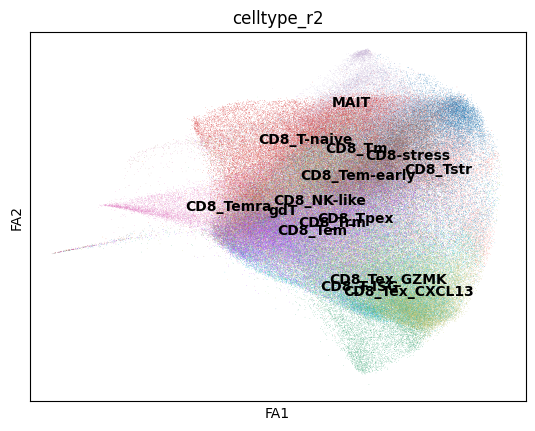

In [8]:
# use the umap to initialize the graph layout.
sc.tl.draw_graph(adata, init_pos='X_umap')
sc.pl.draw_graph(adata, color='celltype_r2', legend_loc='on data')

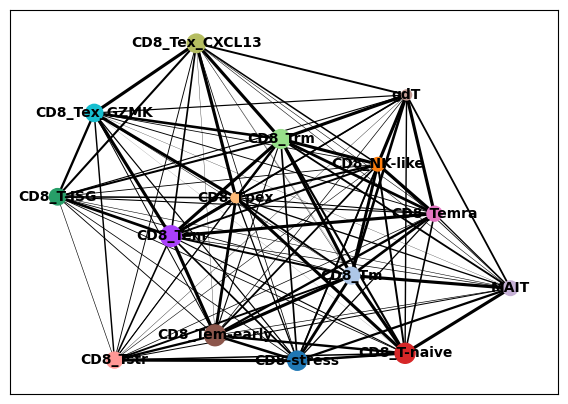

In [9]:
sc.tl.paga(adata, groups='celltype_r2')
sc.pl.paga(adata, color='celltype_r2', edge_width_scale = 0.3)

In [10]:
adata.uns['iroot'] = np.flatnonzero(adata.obs['celltype_r2']  == 'CD8_T-naive')[0]
sc.tl.dpt(adata)

In [12]:
adata

AnnData object with n_obs × n_vars = 274187 × 27973
    obs: 'celltype_r2', 'celltype_main', 'cohort', 'patient', 'time_point', 'treatment', 'dpt_pseudotime'
    var: 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'mean', 'std'
    uns: 'log1p', 'hvg', 'pca', 'neighbors', 'umap', 'celltype_r2_colors', 'cohort_colors', 'draw_graph', 'paga', 'celltype_r2_sizes', 'iroot', 'diffmap_evals'
    obsm: 'X_pca', 'X_umap', 'X_draw_graph_fa', 'X_diffmap'
    varm: 'PCs'
    obsp: 'distances', 'connectivities'

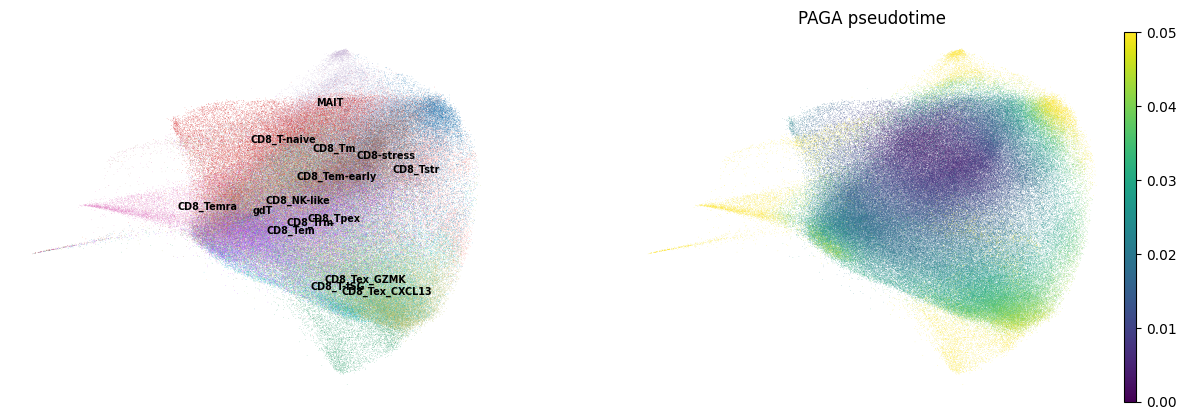

In [11]:
sc.pl.draw_graph(adata, color=['celltype_r2', 'dpt_pseudotime'], legend_loc='on data', legend_fontsize= 'x-small', vmax=0.05, frameon=False, title = ['','PAGA pseudotime'])

In [22]:
gc.collect()

10921

In [1]:
sc.pl.umap(adata, color=['celltype_r2','cohort'])

NameError: name 'sc' is not defined